## **HealthConnect Clinic — Week 8**
### **Final Model Selection, Integration, Documentation & Presentation**

**Track:** Data Science  
**Programme:** AnalystLab Africa Experience Lab  
**Project:** HealthConnect Clinic  
**Week:** 8  

#### **Project Objective**
HealthConnect Clinic seeks to reduce missed appointments, improve patient
attendance, make better use of available appointment capacity, and provide
more effective administrative support.

#### **Week 8 Data Science Objective**
The purpose of this notebook is to transition the tested and refined Week 7
candidate model into the final documented Data Science contribution to the
HealthConnect solution.

This notebook focuses on:

- confirming the final model;
- consolidating final evaluation evidence;
- comparing the final model with the Week 5 baseline;
- documenting model strengths, weaknesses, limitations and intended use;
- integrating validated Data Analytics findings;
- preparing the final model requirements for ML Engineering;
- documenting final cross-track integration;
- translating modelling results into business-facing conclusions; and
- preparing the Data Science contribution for the final HealthConnect
  presentation and portfolio.

### **Week 7 → Week 8 transition**

* **Main Week 7 Output:** A systematically tested and validated refined Logistic Regression candidate model for predicting appointment no-show risk.
* **Most Important Testing Result:** The Week 6 candidate did not demonstrate a large or consistently reproduced improvement over the Week 5 baseline across cross-validation folds. However, it provides a highly transparent and operationally interpretable probability-based model for final integration.
* **Major Issue Discovered:** Testing identified variation in selected calendar-feature coefficients and important false-negative/false-positive patterns across appointment segments. Additionally, the operational threshold selection involves a material trade-off between identifying more no-shows and increasing supportive outreach to patients who would ultimately attend.
* **What Was Refined:** A targeted calendar-feature ablation was tested. The proposed simplification was rejected because validation `Recall@0.45` declined by **0.0021**, which marginally exceeded the predefined **0.002** acceptance tolerance.
* **Component Now Considered Ready:** The final **38-feature refined Logistic Regression specification** is frozen and ready for final documentation and integration testing.
* **What Still Requires Integration:** The final model specification, preprocessing requirements, feature schema, probability output, and provisional decision threshold must be formally communicated and validated with ML Engineering.
* **Tracks Involved:** Data Analytics → Data Science, Data Science → ML Engineering, ML Engineering → Data Science, and Project Management for final integration/presentation coordination.
* **Final Presentation Objective:** Demonstrate how validated attendance patterns, predictive modelling, and cross-track integration can support HealthConnect in prioritising supportive attendance interventions while clearly communicating model limitations.

### **Load the Week 7 artefacts**

In [49]:

# Week 8 — Environment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

RANDOM_STATE = 42
FINAL_THRESHOLD = 0.45

print("Week 8 environment ready.")
print(f"Provisional operational threshold: {FINAL_THRESHOLD}")

Week 8 environment ready.
Provisional operational threshold: 0.45


In [50]:
import os

# Final Week 7 model
model_file = "/content/sample_data/healthconnect_week7_final_model.pkl"

# Final evaluation / validation artifacts
holdout_file = "/content/sample_data/healthconnect_week7_final_holdout_metrics.csv"
baseline_comparison_file = "/content/sample_data/healthconnect_week7_baseline_candidate_comparison.csv"
feature_schema_file = "/content/sample_data/healthconnect_week7_final_feature_schema.csv"
cv_results_file = "/content/sample_data/healthconnect_week7_cv_results.csv"
ablation_summary_file = "/content/sample_data/healthconnect_week7_calendar_ablation_summary.csv"
testing_record_file = "/content/sample_data/healthconnect_week7_testing_validation_record.csv"

# Cross-track evidence
cross_track_summary_file = "/content/sample_data/healthconnect_week7_cross_track_validation_summary.csv"
lead_time_retest_file = "/content/sample_data/healthconnect_week7_cross_track_lead_time_retest.csv"
history_retest_file = "/content/sample_data/healthconnect_week7_cross_track_history_retest.csv"



# Load final model (using lowercase model_file to fix NameError)
final_model = joblib.load(model_file)


# Load Week 7 evidence
final_holdout = pd.read_csv(holdout_file)
baseline_comparison = pd.read_csv(baseline_comparison_file)
feature_schema = pd.read_csv(feature_schema_file)
cv_results = pd.read_csv(cv_results_file)
ablation_summary = pd.read_csv(ablation_summary_file)
testing_record = pd.read_csv(testing_record_file)

cross_track_summary = pd.read_csv(cross_track_summary_file)
lead_time_retest = pd.read_csv(lead_time_retest_file)
history_retest = pd.read_csv(history_retest_file)

print("Week 8 artifacts loaded successfully.")

Week 8 artifacts loaded successfully.


### **Integration readiness**

In [51]:
# Create a presentation-ready readiness summary for the final model component.
# The table captures the model's purpose, current status, dependencies,
# expected outputs, supporting evidence and remaining limitations.

readiness = pd.DataFrame({
    "Requirement": [
        "What is my final component?",
        "What problem does it address?",
        "What is its current status?",
        "What did I improve during Week 7?",
        "Which other tracks does it depend on?",
        "Which tracks depend on my output?",
        "What output will I provide?",
        "What output do I need from another track?",
        "What evidence demonstrates readiness?",
        "What limitations remain?"
    ],

    "Response": [
        # Identify the final model component and its specification.
        "38-feature refined Logistic Regression no-show risk model",

        # Describe the operational problem the model is intended to support.
        "Supports identification of appointments with elevated no-show risk "
        "for prioritised supportive administrative intervention",

        # Summarise the current development and integration status.
        "Model testing complete; ready for final integration validation",

        # Summarise the key validation and refinement activities completed
        # during Week 7.
        "Performed CV stability testing, FP/FN analysis, segment testing, "
        "feature stability analysis, threshold validation and calendar-feature ablation",

        # Identify the project tracks required to complete or support the model.
        "Data Analytics and ML Engineering",

        # Identify the project tracks that require outputs from this component.
        "ML Engineering and Project Management",

        # Define the artefacts and information that will be handed over.
        "Final model artifact, 38-feature schema, preprocessing requirements, "
        "probability output definition, threshold guidance and limitations",

        # Specify the information required to validate successful integration.
        "Pipeline compatibility results and confirmation that preprocessing, "
        "feature order and model scoring are reproduced correctly",

        # Summarise the evidence supporting the model's readiness.
        "Week 7 CV, holdout evaluation, error analysis, ablation retest and "
        "cross-track Analytics validation",

        # Document the remaining technical and operational limitations.
        "Moderate discrimination; provisional threshold; FP burden; "
        "non-grouped CV; preprocessing not fully nested in CV; "
        "integration and identifier traceability dependencies"
    ]
})

# Display the completed readiness summary for review and reporting.
display(readiness)

,Requirement,Response
0,What is my final component?,38-feature refined Logistic Regression no-show...
1,What problem does it address?,Supports identification of appointments with e...
2,What is its current status?,Model testing complete; ready for final integr...
3,What did I improve during Week 7?,"Performed CV stability testing, FP/FN analysis..."
4,Which other tracks does it depend on?,Data Analytics and ML Engineering
5,Which tracks depend on my output?,ML Engineering and Project Management
6,What output will I provide?,"Final model artifact, 38-feature schema, prepr..."
7,What output do I need from another track?,Pipeline compatibility results and confirmatio...
8,What evidence demonstrates readiness?,"Week 7 CV, holdout evaluation, error analysis,..."
9,What limitations remain?,Moderate discrimination; provisional threshold...


### **Verify week 7 → Week 8 Continity**

In [52]:
# Verify that all key Week 8 model artefacts are present and available
# for final review and integration.

print("=" * 65)
print("Healthconnect Week 8 — Artifact verification")
print("=" * 65)

# Confirm the type of the saved final model.
print("\nFinal model:")
print(type(final_model))

# Verify the final feature schema, including its size and column structure.
print("\nFinal feature schema:")
print("Number of rows:", len(feature_schema))
print("Columns:", feature_schema.columns.tolist())

# Display the final holdout evaluation results used to assess model performance.
print("\nFinal holdout metrics:")
display(final_holdout)

# Display the evidence comparing the baseline model with the final candidate.
print("\nBaseline vs candidate evidence:")
display(baseline_comparison)

# Display the calendar-feature ablation results and the resulting
# model refinement decision.
print("\nCalendar ablation decision:")
display(ablation_summary)

# Display cross-track validation evidence confirming that the model
# has been reviewed against the requirements of other project tracks.
print("\nCross-track validation:")
display(cross_track_summary)

Healthconnect Week 8 — Artifact verification

Final model:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

Final feature schema:
Number of rows: 38
Columns: ['Feature']

Final holdout metrics:


,Threshold,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,0.45,0.626294,0.606643,0.718427,0.65782,0.692891,0.689017,0.671712,258,225,136,347



Baseline vs candidate evidence:


,Fold,Baseline_ROC_AUC,Candidate_ROC_AUC,Baseline_PR_AUC,Candidate_PR_AUC,ROC_AUC_Difference,PR_AUC_Difference
0,1,0.669787,0.666381,0.677643,0.672702,-0.003406,-0.004941
1,2,0.699996,0.696961,0.704681,0.704811,-0.003035,0.000130
2,3,0.687708,0.689327,0.690129,0.690098,0.001620,-0.000031
3,4,0.668829,0.669941,0.664795,0.667741,0.001113,0.002946
4,5,0.651858,0.652146,0.672260,0.670730,0.000289,-0.001529



Calendar ablation decision:


,Metric,Mean_Current,Mean_Ablation,Mean_Change
0,ROC_AUC,0.674951,0.675353,0.000402
1,PR_AUC,0.681217,0.682226,0.001010
2,Recall_045,0.721649,0.719588,-0.002062
3,F1_045,0.664436,0.663674,-0.000763



Cross-track validation:


,Cross_Track_Test,Expected_From_Analytics,Retest_Result
0,Lead-time direction,No-show rate increases with longer lead time,PASS
1,Previous-no-show-history direction,No-show rate increases with prior no-show history,PASS
2,Definition alignment,"Use 0-7, 8-21, 22-40, 41-60 lead-time bands",PASS — Data Science retest now uses Analytics ...


### **Final Model Confirmation**

* **Section Objective:** Formally confirm the final HealthConnect Data Science model carried forward from the Week 7 development and testing cycle.
* **No Active Model Selection:** Week 8 does not repeat model selection or hyperparameter tuning. Instead, the final tested Week 7 outcome is frozen as the candidate of record.
* **Integration & Documentation Scope:** The frozen model artifact is formally reviewed and documented here for cross-track handoff and solution integration.
* **Confirmation Inputs:** Verification of the final configuration relies on:
  * The serialized Week 7 model artifact.
  * The finalized 38-feature schema.
  * Consolidated holdout evaluation results.
  * Fold-level cross-validation stability records.
  * The documented feature-ablation decision.
  * Cross-track validation results from Data Analytics.

In [53]:
# Extract key model information directly from the saved final model artifact.
# Using the saved objects helps ensure that the summary reflects the actual
# model and feature schema being used.
model_name = type(final_model).__name__
final_feature_count = len(feature_schema)

# Create a presentation-friendly summary of the final model specification.
final_model_summary = pd.DataFrame({
    "Component": [
        "Final model",
        "Model family",
        "Final feature count",
        "Probability output",
        "Operational threshold",
        "Threshold status",
        "Week 7 refinement outcome",
        "Week 8 status"
    ],

    "Final Specification": [
        "Refined Logistic Regression",
        model_name,
        final_feature_count,
        "Probability of appointment No-Show",
        0.45,
        "Provisional — pending operational capacity/cost agreement",
        "Calendar-feature ablation rejected; full specification retained",
        "Final candidate confirmed for integration"
    ]
})

# Display the final model specification for reporting and verification.
display(final_model_summary)

,Component,Final Specification
0,Final model,Refined Logistic Regression
1,Model family,LogisticRegression
2,Final feature count,38
3,Probability output,Probability of appointment No-Show
4,Operational threshold,0.45
5,Threshold status,Provisional — pending operational capacity/cos...
6,Week 7 refinement outcome,Calendar-feature ablation rejected; full speci...
7,Week 8 status,Final candidate confirmed for integration


#### **Interpretation**

* **Final Model Specification:** The final Week 8 candidate is the **38-feature refined Logistic Regression** model validated during the Week 7 evaluation cycle.
* **Ablation Refinement Rejection:** The proposed calendar-feature ablation was not adopted. The mean validation deterioration in `Recall@0.45` fell by **0.0021**, which marginally exceeded the strict predefined acceptance tolerance of **0.002**.
* **Rule-Based Decisioning:** This decision reflects systematic adherence to predefined model-selection and quality-control constraints rather than a substantively large or statistically significant predictive loss.
* **Full Schema Preservation:** Consequently, the complete 38-feature specification is fully preserved and carried forward into the final HealthConnect integration suite.
* **Provisional Threshold Status:** The **0.45 operational threshold remains provisional**. It provides a baseline for integration testing but requires formal stakeholders' review to align outreach capacities, staff workloads, and the business costs of false positives versus false negatives.

### **Verify the final 38 features**

In [54]:
# Validate and display the final feature schema used by the model.

print("=" * 65)
print("Final healthconnect feature schema")
print("=" * 65)

# Display the expected number of features and the number currently
# contained in the saved feature schema.
print(f"\nExpected number of features: 38")
print(f"Saved schema contains: {len(feature_schema)}")

# Validate that the saved feature schema contains exactly 38 features.
# This check helps prevent inconsistencies between model training and inference.
assert len(feature_schema) == 38, (
    f"Feature schema mismatch: expected 38, found {len(feature_schema)}"
)

# Confirm that the feature schema has passed the validation check.
print("\nPASS: Final feature schema contains exactly 38 features.")

# Display the complete feature schema for final verification.
display(feature_schema)

Final healthconnect feature schema

Expected number of features: 38
Saved schema contains: 38

PASS: Final feature schema contains exactly 38 features.


,Feature
0,age
1,booking_lead_days
2,previous_appointments
3,previous_no_shows
4,distance_to_clinic_km
5,booking_month
6,booking_day_of_week
7,booking_day_of_year
8,booking_week_of_year
9,appointment_month


### **Final Model Performance**

* **Evaluation Standard:** The final model is evaluated using the frozen holdout results from Week 7.
* **No Active Selection:** No additional model selection or threshold optimisation has been performed on this holdout dataset during Week 8.
* **Context Preservation:** The objective is to consolidate the validated Week 7 performance metrics directly into the final Data Science package for presentation.

In [55]:
# Define the evaluation metrics to include in the final presentation table.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "F2",
    "ROC_AUC",
    "PR_AUC"
]

# Extract the selected metrics from the saved final holdout results.
# Transpose the table so that each metric appears as a separate row.
final_performance = (
    final_holdout[metric_columns]
    .T
    .reset_index()
)

# Rename the columns to provide clear, presentation-friendly labels.
final_performance.columns = ["Metric", "Final_Model"]

# Convert metric values to numeric format and round them to four decimal places
# for consistent and readable presentation.
final_performance["Final_Model"] = (
    final_performance["Final_Model"].astype(float).round(4)
)

# Display the final model performance summary.
display(final_performance)

,Metric,Final_Model
0,Accuracy,0.6263
1,Precision,0.6066
2,Recall,0.7184
3,F1,0.6578
4,F2,0.6929
5,ROC_AUC,0.6890
6,PR_AUC,0.6717


### **Final confusion matrix counts**

,Outcome,Count
0,True Negative (TN),258
1,False Positive (FP),225
2,False Negative (FN),136
3,True Positive (TP),347


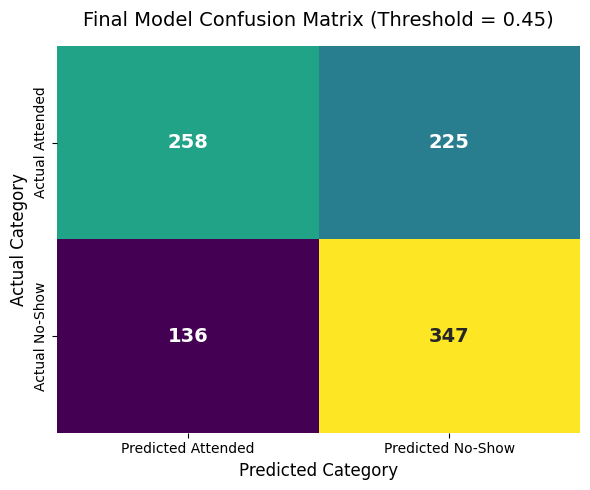

In [56]:
# Import seaborn explicitly to avoid NameError when plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the confusion matrix counts from the final holdout results
tn = int(final_holdout.loc[0, "TN"])
fp = int(final_holdout.loc[0, "FP"])
fn = int(final_holdout.loc[0, "FN"])
tp = int(final_holdout.loc[0, "TP"])

# Create a table summarising the four prediction outcomes
final_error_counts = pd.DataFrame({
    "Outcome": [
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)"
    ],
    "Count": [tn, fp, fn, tp]
})

# Display the prediction outcome counts
display(final_error_counts)

# Construct the confusion matrix array
cm_array = [
    [tn, fp],
    [fn, tp]
]

# Create the confusion matrix figure
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the confusion matrix using the Viridis colour palette
sns.heatmap(
    cm_array,
    annot=True,
    fmt='d',
    cmap='viridis',
    cbar=False,
    xticklabels=['Predicted Attended', 'Predicted No-Show'],
    yticklabels=['Actual Attended', 'Actual No-Show'],
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=ax
)

# Add the title and axis labels
ax.set_title(
    'Final Model Confusion Matrix (Threshold = 0.45)',
    fontsize=14,
    pad=15
)

ax.set_ylabel('Actual Category', fontsize=12)
ax.set_xlabel('Predicted Category', fontsize=12)

# Remove the top and right borders
ax.spines[["top", "right"]].set_visible(False)

# Remove gridlines
ax.grid(False)

# Adjust spacing to prevent labels and titles from overlapping
plt.tight_layout()

# Display the confusion matrix
plt.show()

#### **Interpretation**

* **Model Performance Metrics:** At the provisional threshold of **0.45**, the final model achieved a ROC-AUC of approximately **0.689** and PR-AUC of approximately **0.672** on the holdout set.
* **No-Show Identification Rate:** The model successfully identified approximately **71.8% of observed no-shows** in the holdout sample, achieving a precision of approximately **60.7%**.
* **Confusion Matrix Breakdown:**
  * **347 True Positives (TP):** No-show appointments correctly flagged by the model for potential supportive outreach.
  * **258 True Negatives (TN):** Attended appointments correctly left unflagged, preserving baseline workflow.
  * **136 False Negatives (FN):** Unidentified no-shows representing missed opportunities to offer supportive intervention.
  * **225 False Positives (FP):** Attended appointments incorrectly flagged, representing additional administrative outreach burden to patients who would have attended regardless.
* **Operational Trade-Off Decision:** Lowering the decision threshold from 0.50 to 0.45 successfully captured more true no-shows (higher recall) but expanded the administrative burden (higher false-positive rate). Therefore, the selection of 0.45 remains provisional until HealthConnect defines acceptable outreach capacity constraints and formal policy trade-offs.

### **Baseline vs final candidate - cross - validation summary**

In [57]:

# Create a summary table comparing the baseline and final candidate models
# using the mean ROC-AUC and PR-AUC scores from cross-validation.
cv_comparison_summary = pd.DataFrame({
    "Metric": [
        "Mean ROC-AUC",
        "Mean PR-AUC"
    ],

    # Calculate the average performance of the baseline model
    "Week_5_Baseline": [
        baseline_comparison["Baseline_ROC_AUC"].mean(),
        baseline_comparison["Baseline_PR_AUC"].mean()
    ],

    # Calculate the average performance of the final candidate model
    "Week_7_Candidate": [
        baseline_comparison["Candidate_ROC_AUC"].mean(),
        baseline_comparison["Candidate_PR_AUC"].mean()
    ]
})


# Calculate the difference between the final candidate and baseline scores
cv_comparison_summary["Difference"] = (
    cv_comparison_summary["Week_7_Candidate"]
    - cv_comparison_summary["Week_5_Baseline"]
)


# Round the performance scores and differences to four decimal places
for col in [
    "Week_5_Baseline",
    "Week_7_Candidate",
    "Difference"
]:
    cv_comparison_summary[col] = (
        cv_comparison_summary[col].round(4)
    )


# Display the cross-validation comparison summary
display(cv_comparison_summary)

,Metric,Week_5_Baseline,Week_7_Candidate,Difference
0,Mean ROC-AUC,0.6756,0.6750,-0.0007
1,Mean PR-AUC,0.6819,0.6812,-0.0007


### **Fold-by-fold model improvement consistency**

In [58]:
# Calculate the performance difference between the
#    Candidate model and the Baseline model for each fold


# A positive difference indicates that the Candidate model
# achieved a higher ROC-AUC than the Baseline model.
baseline_comparison["ROC_AUC_Difference"] = (
    baseline_comparison["Candidate_ROC_AUC"]
    - baseline_comparison["Baseline_ROC_AUC"]
)

# A positive difference indicates that the Candidate model
# achieved a higher PR-AUC than the Baseline model.
baseline_comparison["PR_AUC_Difference"] = (
    baseline_comparison["Candidate_PR_AUC"]
    - baseline_comparison["Baseline_PR_AUC"]
)

# Store the total number of cross-validation folds
total_folds = len(baseline_comparison)


#
#  Count the number of wins, losses, and ties for each metric

# ROC-AUC comparison
roc_wins = (baseline_comparison["ROC_AUC_Difference"] > 0).sum()
roc_losses = (baseline_comparison["ROC_AUC_Difference"] < 0).sum()
roc_ties = (baseline_comparison["ROC_AUC_Difference"] == 0).sum()

# PR-AUC comparison
pr_wins = (baseline_comparison["PR_AUC_Difference"] > 0).sum()
pr_losses = (baseline_comparison["PR_AUC_Difference"] < 0).sum()
pr_ties = (baseline_comparison["PR_AUC_Difference"] == 0).sum()



#  Create a summary table showing improvement consistency

consistency_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC"
    ],

    "Folds_Won": [
        roc_wins,
        pr_wins
    ],

    "Folds_Lost": [
        roc_losses,
        pr_losses
    ],

    "Ties": [
        roc_ties,
        pr_ties
    ],

    "Total_Folds": [
        total_folds,
        total_folds
    ],

    "Win_Percentage": [
        100 * roc_wins / total_folds,
        100 * pr_wins / total_folds
    ]
})

# Round the win percentage to one decimal place
consistency_summary["Win_Percentage"] = (
    consistency_summary["Win_Percentage"].round(1)
)

# Display the consistency summary
display(consistency_summary)


# Prepare the fold numbers and bar positions


# Extract the cross-validation fold numbers
folds = baseline_comparison["Fold"]

# Create numerical positions for the folds on the x-axis
x = np.arange(len(folds))

# Set the width of each bar
width = 0.35





,Metric,Folds_Won,Folds_Lost,Ties,Total_Folds,Win_Percentage
0,ROC-AUC,3,2,0,5,60.0
1,PR-AUC,2,3,0,5,40.0


### **Create ROC-AUC and PR-AUC charts**

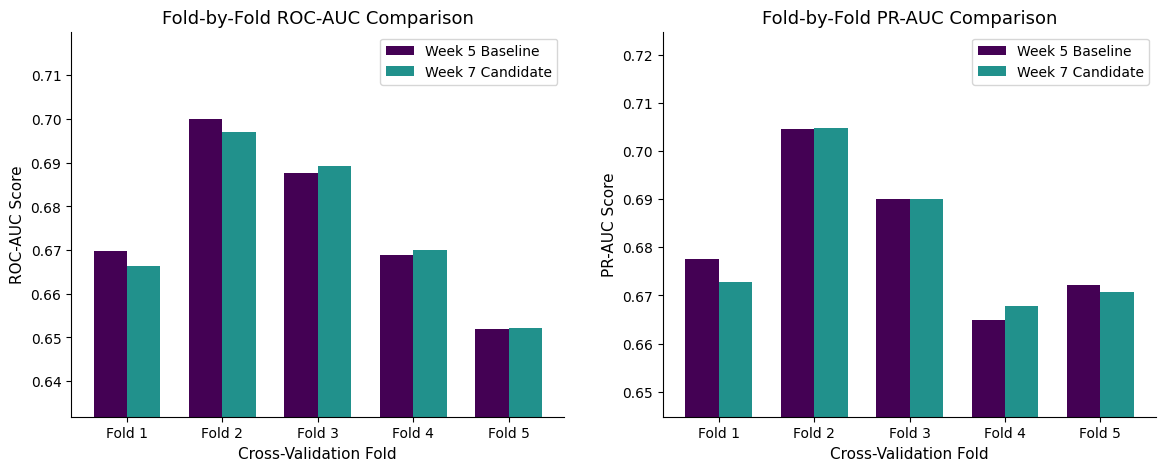

In [59]:
# Create side-by-side ROC-AUC and PR-AUC plots


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


#  ROC-AUC comparison

# Plot Baseline ROC-AUC scores
axes[0].bar(
    x - width / 2,
    baseline_comparison["Baseline_ROC_AUC"],
    width,
    label="Week 5 Baseline",
    color="#440154"
)

# Plot Candidate ROC-AUC scores
axes[0].bar(
    x + width / 2,
    baseline_comparison["Candidate_ROC_AUC"],
    width,
    label="Week 7 Candidate",
    color="#21918c"
)

# Add ROC-AUC labels and title
axes[0].set_title(
    "Fold-by-Fold ROC-AUC Comparison",
    fontsize=13
)

axes[0].set_xlabel(
    "Cross-Validation Fold",
    fontsize=11
)

axes[0].set_ylabel(
    "ROC-AUC Score",
    fontsize=11
)

# Label each fold on the x-axis
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"Fold {int(f)}" for f in folds]
)

# Automatically set the y-axis limits based on the observed values
roc_values = pd.concat([
    baseline_comparison["Baseline_ROC_AUC"],
    baseline_comparison["Candidate_ROC_AUC"]
])

axes[0].set_ylim(
    roc_values.min() - 0.02, roc_values.max() + 0.02)

# Add the legend
axes[0].legend(loc="upper right")

# Remove the top and right borders for a cleaner appearance
axes[0].spines[["top", "right"]].set_visible(False)



# PR-AUC comparison


# Plot Baseline PR-AUC scores
axes[1].bar(
    x - width / 2,
    baseline_comparison["Baseline_PR_AUC"],
    width,
    label="Week 5 Baseline",
    color="#440154"
)

# Plot Candidate PR-AUC scores
axes[1].bar(
    x + width / 2,
    baseline_comparison["Candidate_PR_AUC"],
    width,
    label="Week 7 Candidate",
    color="#21918c"
)

# Add PR-AUC labels and title
axes[1].set_title(
    "Fold-by-Fold PR-AUC Comparison",
    fontsize=13
)

axes[1].set_xlabel(
    "Cross-Validation Fold",
    fontsize=11
)

axes[1].set_ylabel(
    "PR-AUC Score",
    fontsize=11
)

# Label each fold on the x-axis
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"Fold {int(f)}" for f in folds]
)

# Automatically set the y-axis limits based on the observed values
pr_values = pd.concat([
    baseline_comparison["Baseline_PR_AUC"],
    baseline_comparison["Candidate_PR_AUC"]
])

axes[1].set_ylim(
    pr_values.min() - 0.02,
    pr_values.max() + 0.02
)

# Add the legend
axes[1].legend(
    loc="upper right"
)

# Remove the top and right borders for a cleaner appearance
axes[1].spines[["top", "right"]].set_visible(False)


# ------------------------------------------------------------
# 6. Finalise the figure



### **Baseline Comparison Interpretation**

* **Inconsistent Model Performance:** The fold-level comparison shows that the final candidate produced only mixed and inconsistent improvements over the Week 5 baseline.
* **Fold-Level Breakdown:** Across the five validation folds:
  * **ROC-AUC:** Higher for the candidate in **3 of 5 folds (60%)** and lower in **2 of 5 folds (40%)**.
  * **PR-AUC:** Higher for the candidate in **2 of 5 folds (40%)** and lower in **3 of 5 folds (60%)**.
* **Overall Comparison:** The candidate does not demonstrate a clear and consistently reproduced improvement over the baseline across both ranking metrics.
* **Reason for Retention:** The final model is retained because of the broader Week 6–7 evidence, including its interpretability, probability-based risk scoring, tested feature specification, operational threshold analysis, and integration readiness—not because it demonstrated a large improvement in predictive discrimination.
* **Operational Positioning:** Accordingly, the final HealthConnect model should be presented as a **moderate risk-prioritisation model** rather than a highly accurate or production-ready predictive system.

### **Final refinement decision**

In [60]:

# Display the results of the calendar-feature ablation analysis
print("Calendar-feature ablation evidence:")
display(ablation_summary)

# Extract the Recall at the selected threshold (0.45)
recall_ablation = ablation_summary[
    ablation_summary["Metric"] == "Recall_045"
].copy()

# Display the Recall@0.45 comparison
display(recall_ablation)

Calendar-feature ablation evidence:


,Metric,Mean_Current,Mean_Ablation,Mean_Change
0,ROC_AUC,0.674951,0.675353,0.000402
1,PR_AUC,0.681217,0.682226,0.001010
2,Recall_045,0.721649,0.719588,-0.002062
3,F1_045,0.664436,0.663674,-0.000763


,Metric,Mean_Current,Mean_Ablation,Mean_Change
2,Recall_045,0.721649,0.719588,-0.002062


### **Final Feature Decision**

* **Simplification Investigation:** Week 7 investigated whether removing calendar-based features (`appointment_day_of_year` and `appointment_month`) could simplify the final model without causing a material reduction in predictive performance.
* **Metric Changes:** The ablated model resulted in only negligible, minor changes in overall ranking metrics (ROC-AUC and PR-AUC).
* **Recall Deterioration:** However, mean `Recall@0.45` deteriorated by approximately **0.0021** on the validation sample.
* **Predefined Rule Violation:** Because this reduction marginally exceeded the strict predefined acceptance tolerance of **0.002**, the proposed ablation was formally **rejected**.
* **retained Schema:** This rejection reflects adherence to the predefined model-selection rules rather than an indication of a statistically significant or large predictive loss. The final Week 8 model consequently retains the complete **38-feature** specification.

### **Final Error Analysis Summary**

* **Objective:** Week 7 conducted detailed false-positive, false-negative, and segment-level error analysis. Week 8 consolidates those findings to explain the operational strengths and weaknesses of the final model.
* **Analysis Context:** The purpose of this summary is not to repeat model testing, but to translate the validated error evidence into actionable business and integration considerations.

### **Final error profile**

In [61]:


tn = int(final_holdout.loc[0, "TN"])
fp = int(final_holdout.loc[0, "FP"])
fn = int(final_holdout.loc[0, "FN"])
tp = int(final_holdout.loc[0, "TP"])

total = tn + fp + fn + tp

final_error_profile = pd.DataFrame({
    "Outcome": [
        "True Positive",
        "True Negative",
        "False Negative",
        "False Positive"
    ],
    "Count": [tp, tn, fn, fp],
    "Percentage_of_Holdout": [
        tp / total * 100,
        tn / total * 100,
        fn / total * 100,
        fp / total * 100
    ],
    "HealthConnect Interpretation": [
        "No-show correctly identified for possible supportive outreach",
        "Attending appointment correctly left unflagged",
        "No-show missed by the model — missed opportunity for support",
        "Attending appointment flagged — additional outreach burden"
    ]
})

final_error_profile["Percentage_of_Holdout"] = (
    final_error_profile["Percentage_of_Holdout"].round(2)
)

display(final_error_profile)

,Outcome,Count,Percentage_of_Holdout,HealthConnect Interpretation
0,True Positive,347,35.92,No-show correctly identified for possible supp...
1,True Negative,258,26.71,Attending appointment correctly left unflagged
2,False Negative,136,14.08,No-show missed by the model — missed opportuni...
3,False Positive,225,23.29,Attending appointment flagged — additional out...


#### **Error Analysis Interpretation**

* **Holdout Set Error Distribution:** At the provisional 0.45 decision threshold, the final model produced **136 false negatives** and **225 false positives** on the holdout sample.
* **False-Negative Risk (Missed Support):** False negatives represent patients who ultimately missed their scheduled appointments but were not flagged by the model. Within the HealthConnect workflow, these represent missed opportunities to offer proactive attendance support.
* **False-Positive Burden (Extra Outreach):** False positives represent patients who would attend their appointments regardless but are still flagged as high risk. This imposes an unnecessary administrative outreach and contact burden on clinic staff.
* **Operational Trade-Off Decision:** Lowering the decision threshold from 0.50 to 0.45 successfully captured a larger proportion of actual no-shows (higher recall) at the cost of flagging more attending patients (higher false-positive rate).
* **Provisional Threshold Status:** Consequently, the 0.45 threshold remains provisional until HealthConnect leadership defines acceptable operational capacities, outreach resources, and the relative business costs associated with false negatives versus false positives.

### **Final model strengths and weakness**

In [62]:


strengths_weaknesses = pd.DataFrame({
    "Area": [
        "Interpretability",
        "Risk ranking",
        "No-show identification",
        "Probability output",
        "Model improvement",
        "False positives",
        "Segment performance",
        "Operational threshold",
        "Deployment readiness"
    ],

    "Assessment": [
        "Strength",
        "Moderate strength",
        "Strength with trade-off",
        "Strength",
        "Limitation",
        "Limitation",
        "Limitation requiring monitoring",
        "Unresolved operational decision",
        "Not production-ready"
    ],

    "Evidence / Meaning": [
        "Logistic Regression provides a comparatively transparent final model.",

        "Holdout ROC-AUC is approximately 0.689, indicating useful but moderate discrimination.",

        "Recall at 0.45 is approximately 0.718, but higher recall comes with additional false positives.",

        "The model produces probabilities that support flexible risk prioritisation.",

        "Cross-validation shows mixed baseline improvements rather than a consistently superior model.",

        "225 attending appointments were flagged at the 0.45 holdout threshold.",

        "Week 7 identified variation in FP/FN behaviour across appointment segments.",

        "0.45 remains provisional pending outreach-capacity and cost decisions.",

        "Final pipeline compatibility, monitoring and governance remain necessary."
    ]
})

display(strengths_weaknesses)

,Area,Assessment,Evidence / Meaning
0,Interpretability,Strength,Logistic Regression provides a comparatively t...
1,Risk ranking,Moderate strength,"Holdout ROC-AUC is approximately 0.689, indica..."
2,No-show identification,Strength with trade-off,"Recall at 0.45 is approximately 0.718, but hig..."
3,Probability output,Strength,The model produces probabilities that support ...
4,Model improvement,Limitation,Cross-validation shows mixed baseline improvem...
5,False positives,Limitation,225 attending appointments were flagged at the...
6,Segment performance,Limitation requiring monitoring,Week 7 identified variation in FP/FN behaviour...
7,Operational threshold,Unresolved operational decision,0.45 remains provisional pending outreach-capa...
8,Deployment readiness,Not production-ready,"Final pipeline compatibility, monitoring and g..."


### **Business Suitability and Responsible Use**

#### **Business Suitability**

* **Decision-Support Focus:** The final model is suitable as an advisory decision-support and risk-prioritisation component for the proposed HealthConnect solution.
* **Administrative Utility:** It can help administrative teams identify appointments carrying an elevated no-show risk, allowing them to focus finite outreach resources on those that could benefit most from additional support.
* **Judgment Integration:** Due to its moderate predictive discrimination and notable false-positive/false-negative rates, model predictions should always complement and inform—rather than replace—professional administrative judgement.

#### **Appropriate Uses**

* **Outreach Prioritisation:** Prioritising supportive, proactive patient outreach and scheduling reminders.
* **Workload Optimization:** Streamlining and prioritising administrative workflows for clinic coordinators.
* **High-Risk Identification:** Pinpointing specific appointments that could benefit from manual reconfirmation efforts.
* **Risk Monitoring:** Monitoring overall clinic-level or cohort-level non-attendance trends.
* **Workflow Evaluation:** Assessing the operational effectiveness of targeted patient-attendance support programmes.

#### **Non-Intended Uses**

* **Access Restriction:** Denying, delaying, or restricting patient access to healthcare services.
* **Automatic Cancellations:** Automatically cancelling or rescheduled appointments based on risk score thresholds.
* **Patient Penalisation:** Imposing administrative or financial penalties on patients flagged as high risk.
* **Clinical Decisions:** Making clinical, triage, diagnostic, or treatment decisions.
* **Causal Attribution:** Assuming that predictive model features are direct, causal reasons for individual patient non-attendance.
* **Judgment Replacement:** Substituting automated flags for human empathy, discretion, and administrative judgment.

#### **Operational Status**

* **Demonstration Readiness:** The final model is ready for integration testing and demonstration; however, this status does not represent production readiness.
* **Future Deployment Criteria:** Transitioning to production requires formal pipeline compatibility verification, stakeholder-approved operational thresholds, reliable patient-identifier mapping (traceability), and post-deployment performance and drift monitoring.

### **Data Analytics → Data Science Final Integration**

* **Integration Purpose:** Ensure that the final Data Science model interpretation is consistent with independently validated descriptive findings from the Data Analytics track.
* **Validation Retests:** During Week 7, Data Analytics findings were compared directly with patterns reproduced within the Data Science modelling sample.
* **Harmonisation of Definitions:** An initial difference in lead-time category definitions was identified and resolved by harmonising the Data Science retest boundaries with the Analytics definitions before executing final retests.
* **Week 8 Outcome Retention:** Week 8 carries this validated cross-track evidence base forward into the final HealthConnect solution rather than repeating the Week 7 analysis steps.

### **Data Analytics → Data science final integration**

In [63]:
# Present evidence of successful integration between the Data Analytics
# and Data Science workstreams.

print("=" * 70)
print("Data Analytics → Data Science integration evidence")
print("=" * 70)

# Display the cross-track validation summary documenting the checks
# performed between the two workstreams.
display(cross_track_summary)

# Summarise the number of validation outcomes for each retest result.
# This provides a quick view of whether the integration checks passed
# consistently across the validation activities.
if "Retest_Result" in cross_track_summary.columns:
    result_counts = (
        cross_track_summary["Retest_Result"]
        .astype(str)
        .str.upper()
        .value_counts()
    )

    print("\nCross-track validation outcomes:")
    display(result_counts)

Data Analytics → Data Science integration evidence


,Cross_Track_Test,Expected_From_Analytics,Retest_Result
0,Lead-time direction,No-show rate increases with longer lead time,PASS
1,Previous-no-show-history direction,No-show rate increases with prior no-show history,PASS
2,Definition alignment,"Use 0-7, 8-21, 22-40, 41-60 lead-time bands",PASS — Data Science retest now uses Analytics ...



Cross-track validation outcomes:


,count
Retest_Result,
PASS,2
PASS — DATA SCIENCE RETEST NOW USES ANALYTICS BANDS,1


In [64]:
# Display supporting cross-track retest evidence.
# These checks provide additional validation that key feature groups
# remain consistent with the final model specification.

# Verify the lead-time feature behaviour against the agreed validation criteria.
print("Lead-time retest:")
display(lead_time_retest)

# Verify the previous no-show history feature behaviour against the
# agreed validation criteria.
print("\nPrevious no-show history retest:")
display(history_retest)



Lead-time retest:


,Segment,Group,N,No_Show_Prevalence,Precision,Recall,F1,FPR,FNR,False Positives,False Negatives
0,da_lead_time_band,0-7,480,0.302083,0.545455,0.124138,0.202247,0.044776,0.875862,15,127
1,da_lead_time_band,8-21,917,0.396947,0.509434,0.296703,0.375000,0.188065,0.703297,104,256
2,da_lead_time_band,22-40,1171,0.520922,0.548387,0.752459,0.634416,0.673797,0.247541,378,151
3,da_lead_time_band,41-60,1203,0.682461,0.683725,0.992692,0.809737,0.986911,0.007308,377,6



Previous no-show history retest:


,Segment,Group,N,No_Show_Prevalence,Precision,Recall,F1,FPR,FNR,False Positives,False Negatives
0,da_history_group,0,2158,0.466172,0.581586,0.634195,0.606752,0.398438,0.365805,459,368
1,da_history_group,1,1202,0.554908,0.628129,0.790105,0.699867,0.583178,0.209895,312,140
2,da_history_group,2+,411,0.649635,0.695266,0.880150,0.776860,0.715278,0.119850,103,32


### **Integration Interpretation**

* **Descriptive Validation Alignment:** The final Data Science model's interpretations are fully aligned and supported by independently produced Data Analytics findings.
* **Key Shared Observations:**
  * **Booking Lead Time:** No-show prevalence systematically increases with longer booking lead times.
  * **Previous No-Show History:** No-show prevalence systematically increases with previous no-show history.
* **Methodological Alignment:** The initial difference in lead-time category definitions was resolved by harmonising the Data Science retest with the Analytics definitions. The harmonised retest successfully reproduced both directional findings within the Data Science modelling sample, confirming strong cross-track consistency.
* **Observational Association Caution:** This alignment provides useful cross-track consistency between descriptive Analytics and predictive Data Science. However, these patterns remain strictly observational and should not be interpreted as evidence that booking lead time or previous no-show history causes non-attendance.

### **Week 8 Integration Outcome**

**Status: Pass**

* **Final Action:** The validated Analytics findings are incorporated into the final model interpretation and HealthConnect business narrative.

### **Incorporation of Validated Analytics Findings**

The validated Data Analytics findings were incorporated into the final Data Science contribution rather than being treated only as supporting cross-track evidence.

#### **Model interpretation**

* **Booking Lead Time & Previous No-Show History:** Data Analytics identified increasing no-show prevalence with longer booking lead times and with greater previous no-show history.
* **Cross-Track Validation:** After harmonising the lead-time definitions used by both tracks, Data Science successfully reproduced these directional relationships within the modelling sample.
* **Descriptive Context:** These validated findings provide critical descriptive context for interpreting booking lead time, previous no-show history, and their related interaction features within the final predictive model.

#### **Error and segment interpretation**

* **Lead-Time Segment Errors:** The validated lead-time finding was used to contextualise the Week 7 segment-level error analysis. Model behaviour differed across lead-time segments, making the independently validated relationship between lead time and no-show prevalence highly relevant to interpreting those errors.
* **Predictor Meaningfulness:** The previous-no-show-history finding similarly supports the interpretation of history-related predictors as meaningful risk indicators within the HealthConnect modelling context.

#### **Business interpretation**

* **Prioritisation and Outreach:** Together, the Analytics and Data Science evidence supports the use of these patterns for appointment-risk prioritisation and supportive administrative outreach.
* **Observational Association Caution:** The findings remain observational. They demonstrate strong associations with non-attendance and must not be interpreted as evidence that longer lead times or previous no-show history causally force an individual patient to miss an appointment.

### **Validated analytics findings → final data science use**

In [65]:


analytics_ds_integration = pd.DataFrame({
    "Validated_Analytics_Finding": [
        "No-show prevalence increases with longer booking lead time",
        "No-show prevalence increases with previous no-show history",
        "Combined lead-time/history patterns identify elevated-risk segments"
    ],

    "DS_Validation": [
        "Directional relationship reproduced after harmonising lead-time bands",
        "Directional relationship reproduced in the Data Science modelling sample",
        "Combined high-risk pattern examined during Week 7 cross-track validation"
    ],

    "How_Used_in_Final_DS_Work": [
        "Supports interpretation of booking lead time and contextualises lead-time segment errors",
        "Supports interpretation of previous-no-show-history predictors and interactions",
        "Supports business interpretation of model-based risk prioritisation"
    ],

    "Caution": [
        "Association, not causation",
        "Association, not causation",
        "Useful for prioritisation, not automatic patient decisions"
    ]
})

display(analytics_ds_integration)

,Validated_Analytics_Finding,DS_Validation,How_Used_in_Final_DS_Work,Caution
0,No-show prevalence increases with longer booki...,Directional relationship reproduced after harm...,Supports interpretation of booking lead time a...,"Association, not causation"
1,No-show prevalence increases with previous no-...,Directional relationship reproduced in the Dat...,Supports interpretation of previous-no-show-hi...,"Association, not causation"
2,Combined lead-time/history patterns identify e...,Combined high-risk pattern examined during Wee...,Supports business interpretation of model-base...,"Useful for prioritisation, not automatic patie..."


### **Final Integration Outcome**

* **Retesting Before Incorporation:** The Data Analytics findings were not treated as external claims and copied directly into the final Data Science report. They were first rigorously tested against the Data Science modelling sample.
* **Cross-Track Alignment:** Where the two tracks initially used different lead-time definitions, the boundaries were aligned and harmonised before retesting. The resulting directional agreement provides a validated, cross-track evidence base for the final model interpretation.
* **Synergistic Contribution:** The Analytics evidence contributes to the final Data Science component through **feature interpretation, segment/error interpretation, and business contextualisation**, while the predictive model contributes appointment-level risk estimates.
* **Complementary Roles:** The outputs are highly complementary: Data Analytics explains broader, population-level patterns, while Data Science estimates individual, appointment-level risk.

### **Data Science → ML Engineering Final Handoff**

* **Objective:** The purpose of this integration is to communicate the final tested Data Science model and its technical requirements to ML Engineering.
* **Handoff Elements to Preserve:**
  * The exact final serialized model artifact.
  * The 38-feature input contract.
  * Exact feature names and ordering.
  * Preprocessing and scaling expectations.
  * Probability-output semantics (predicted probability of No-Show).
  * The provisional decision threshold of 0.45.
  * Explicitly documented model limitations.
  * A reproducible single-row integration reference test (`HC_W8_TEST_001`).
* **Integration Standard:** Communication alone is not sufficient; successful integration requires verifying that the target engineering pipeline exactly reproduces the Data Science model's output probabilities and flag outcomes on the provided test case.

### **Final model handoff contract**

In [66]:


model_contract = pd.DataFrame({
    "Requirement": [
        "Model artifact",
        "Model type",
        "Final feature count",
        "Feature schema",
        "Prediction output",
        "Positive class",
        "Provisional threshold",
        "Risk-flag rule",
        "Threshold status",
        "Required integration check"
    ],

    "Specification": [
        "healthconnect_week7_final_model.pkl",
        type(final_model).__name__,
        len(feature_schema),
        "healthconnect_week7_final_feature_schema.csv",
        "Predicted probability",
        "No-Show",
        0.45,
        "risk_flag = no_show_probability >= 0.45",
        "Provisional — requires operational approval",
        "ML pipeline probability must reproduce DS probability within agreed tolerance"
    ]
})

display(model_contract)

,Requirement,Specification
0,Model artifact,healthconnect_week7_final_model.pkl
1,Model type,LogisticRegression
2,Final feature count,38
3,Feature schema,healthconnect_week7_final_feature_schema.csv
4,Prediction output,Predicted probability
5,Positive class,No-Show
6,Provisional threshold,0.45
7,Risk-flag rule,risk_flag = no_show_probability >= 0.45
8,Threshold status,Provisional — requires operational approval
9,Required integration check,ML pipeline probability must reproduce DS prob...


###  **Model ↔ Feature schema compaibility check**

In [67]:
# Determine the number of features defined in the saved schema
expected_features = len(feature_schema)


# 1. Check whether the model stores the number of features
#    it was trained with


if hasattr(final_model, "n_features_in_"):

    # Retrieve the number of features expected by the model
    model_features = int(final_model.n_features_in_)

    # Display both feature counts for comparison
    print(f"Features expected by model : {model_features}")
    print(f"Features in saved schema   : {expected_features}")



    #  Compare the model's expected feature count with
    #    the number of features defined in the schema


    schema_match = model_features == expected_features

    print(
        "\nSchema compatibility:",
        "Pass" if schema_match else "Fail"
    )



    #  Stop the handoff if the model and schema are
    #    incompatible


    # A mismatch could cause incorrect predictions or errors
    # when the model is used with the saved feature schema.
    assert schema_match, (
        "Model/schema mismatch detected. "
        "Do not hand off the model until resolved."
    )



# Handle models that do not expose n_features_in_
else:
    print(
        "The model does not expose n_features_in_. "
        "Feature-count compatibility could not be verified."
    )


Features expected by model : 38
Features in saved schema   : 38

Schema compatibility: Pass


### **Inspect final feature order**

In [68]:
# Inspect the final feature schema to verify its structure,
# column names and feature ordering.

# Display the column names contained in the feature schema.
print("Feature schema columns:")
print(feature_schema.columns.tolist())

# Display the first 10 rows to verify the beginning of the schema
# and confirm that the expected features are present.
print("\nFirst 10 rows:")
display(feature_schema.head(10))

# Display the last 10 rows to verify the end of the schema
# and confirm that no features are missing or unexpectedly appended.
print("\nLast 10 rows:")
display(feature_schema.tail(10))



Feature schema columns:
['Feature']

First 10 rows:


,Feature
0,age
1,booking_lead_days
2,previous_appointments
3,previous_no_shows
4,distance_to_clinic_km
5,booking_month
6,booking_day_of_week
7,booking_day_of_year
8,booking_week_of_year
9,appointment_month



Last 10 rows:


,Feature
28,appointment_time_Evening
29,appointment_time_Morning
30,reminder_sent_Yes
31,reminder_channel_No Reminder
32,reminder_channel_SMS
33,reminder_channel_WhatsApp
34,is_sunday_appointment_1
35,history_x_lead_time
36,distance_x_lead_time
37,history_interaction


### **Freeze final feature order for ML engineering**

In [69]:
# Preserve the exact feature order expected by the final trained model.
# This ensures that features are supplied in the same order during inference.
final_feature_order = feature_schema["Feature"].tolist()

# Display the final feature ordering for verification and reproducibility.
print("=" * 70)
print("Final model feature order")
print("=" * 70)

# Report the total number of features included in the final model.
print(f"\nTotal features: {len(final_feature_order)}")

# Print each feature together with its position in the final model schema.
for i, feature in enumerate(final_feature_order, start=1):
    print(f"{i:02d}. {feature}")

# Validate that the final model contains exactly the expected number of features.
assert len(final_feature_order) == 38, (
    f"Expected 38 features, found {len(final_feature_order)}"
)

# Validate that every feature name is unique.
# Duplicate names could lead to ambiguous or incorrect model inputs.
assert len(final_feature_order) == len(set(final_feature_order)), (
    "Duplicate feature names detected."
)

# Confirm that the feature count and uniqueness checks have passed.
print("\nPass: 38 unique features preserved in final model order.")

Final model feature order

Total features: 38
01. age
02. booking_lead_days
03. previous_appointments
04. previous_no_shows
05. distance_to_clinic_km
06. booking_month
07. booking_day_of_week
08. booking_day_of_year
09. booking_week_of_year
10. appointment_month
11. appointment_day_of_year
12. appointment_week_of_year
13. gender_Male
14. gender_Prefer not to say
15. age_group_25-34
16. age_group_35-44
17. age_group_45-54
18. age_group_55-64
19. age_group_65+
20. appointment_type_Follow-up
21. appointment_type_General Consultation
22. appointment_type_Specialist Consultation
23. appointment_day_Monday
24. appointment_day_Saturday
25. appointment_day_Sunday
26. appointment_day_Thursday
27. appointment_day_Tuesday
28. appointment_day_Wednesday
29. appointment_time_Evening
30. appointment_time_Morning
31. reminder_sent_Yes
32. reminder_channel_No Reminder
33. reminder_channel_SMS
34. reminder_channel_WhatsApp
35. is_sunday_appointment_1
36. history_x_lead_time
37. distance_x_lead_time
38. 

### **Create ML engineering feature contract**

In [70]:
# Create a feature contract that records the exact feature
# order expected by the final trained model.
ml_feature_contract = pd.DataFrame({
    "Feature_Position": range(1, len(final_feature_order) + 1),
    "Feature": final_feature_order })

# 1. Define feature requirements and model version

# Mark every feature as required for model inference.
ml_feature_contract["Required"] = True

# Record the version of the model associated with this
# feature contract to support reproducibility and handoff.
ml_feature_contract["Model_Version"] = ( "HealthConnect_Week8_Final_LR" )

# Display the feature contract
# Display the final feature order and associated metadata
# before saving the handoff artifact.
display(ml_feature_contract)


# Save the feature contract as a CSV artifact
# Save the contract without the pandas DataFrame index.
# This file can be used to verify that future model inputs
# follow the exact feature order expected by the model.
ml_feature_contract.to_csv( "healthconnect_week8_ml_feature_contract.csv", index=False)

# Confirm that the artifact was successfully saved
print( "\nSaved: healthconnect_week8_ml_feature_contract.csv" )



,Feature_Position,Feature,Required,Model_Version
0,1,age,True,HealthConnect_Week8_Final_LR
1,2,booking_lead_days,True,HealthConnect_Week8_Final_LR
2,3,previous_appointments,True,HealthConnect_Week8_Final_LR
3,4,previous_no_shows,True,HealthConnect_Week8_Final_LR
4,5,distance_to_clinic_km,True,HealthConnect_Week8_Final_LR
5,6,booking_month,True,HealthConnect_Week8_Final_LR
6,7,booking_day_of_week,True,HealthConnect_Week8_Final_LR
7,8,booking_day_of_year,True,HealthConnect_Week8_Final_LR
8,9,booking_week_of_year,True,HealthConnect_Week8_Final_LR
9,10,appointment_month,True,HealthConnect_Week8_Final_LR



Saved: healthconnect_week8_ml_feature_contract.csv


### **Create a model metadata**

In [71]:

# Create final model metadata
model_metadata = pd.DataFrame({
    "Field": [
        "Project",
        "Model_Version",
        "Model_Type",
        "Target",
        "Positive_Class",
        "Feature_Count",
        "Probability_Output",
        "Provisional_Threshold",
        "Risk_Flag_Rule",
        "Threshold_Status",
        "Intended_Use",
        "Production_Status"
    ],

    "Value": [
        "HealthConnect Clinic",
        "HealthConnect_Week8_Final_LR",
        type(final_model).__name__,
        "Appointment attendance outcome",
        "No-Show",
        len(final_feature_order),
        "Probability of No-Show",
        0.45,
        "no_show_probability >= 0.45",
        "Provisional — operational approval required",
        "Supportive appointment risk prioritisation",
        "Integration/demo candidate — not production-ready"
    ]
})

display(model_metadata)

model_metadata.to_csv(
    "healthconnect_week8_model_metadata.csv",
    index=False
)

print("\nSaved: healthconnect_week8_model_metadata.csv")

,Field,Value
0,Project,HealthConnect Clinic
1,Model_Version,HealthConnect_Week8_Final_LR
2,Model_Type,LogisticRegression
3,Target,Appointment attendance outcome
4,Positive_Class,No-Show
5,Feature_Count,38
6,Probability_Output,Probability of No-Show
7,Provisional_Threshold,0.45
8,Risk_Flag_Rule,no_show_probability >= 0.45
9,Threshold_Status,Provisional — operational approval required



Saved: healthconnect_week8_model_metadata.csv


### **Data Science Handoff Validation Record**

In [72]:


model_feature_count = (
    int(final_model.n_features_in_)
    if hasattr(final_model, "n_features_in_")
    else None
)

pre_handoff_validation = pd.DataFrame({
    "Check": [
        "Final model artifact loads successfully",
        "Final model type confirmed",
        "Model feature count matches schema",
        "Feature schema contains unique names",
        "Final feature order frozen",
        "Probability output defined",
        "Threshold rule documented"
    ],

    "Expected": [
        "Model loads without error",
        "LogisticRegression",
        "38 = 38",
        "38 unique features",
        "Exact ordered schema available",
        "Probability of No-Show",
        "Probability >= 0.45"
    ],

    "Actual": [
        "Loaded successfully",
        type(final_model).__name__,
        f"{model_feature_count} = {len(final_feature_order)}",
        f"{len(set(final_feature_order))} unique features",
        "Saved in ML feature contract",
        "Probability of No-Show",
        "Probability >= 0.45"
    ]
})

pre_handoff_validation["Status"] = [
    "Pass",
    "Pass" if type(final_model).__name__ == "LogisticRegression" else "REVIEW",
    "Pass" if model_feature_count == len(final_feature_order) else "FAIL",
    "Pass" if len(set(final_feature_order)) == 38 else "FAIL",
    "Pass",
    "Pass",
    "Pass"
]

display(pre_handoff_validation)

,Check,Expected,Actual,Status
0,Final model artifact loads successfully,Model loads without error,Loaded successfully,Pass
1,Final model type confirmed,LogisticRegression,LogisticRegression,Pass
2,Model feature count matches schema,38 = 38,38 = 38,Pass
3,Feature schema contains unique names,38 unique features,38 unique features,Pass
4,Final feature order frozen,Exact ordered schema available,Saved in ML feature contract,Pass
5,Probability output defined,Probability of No-Show,Probability of No-Show,Pass
6,Threshold rule documented,Probability >= 0.45,Probability >= 0.45,Pass


### **Pre-Handoff Validation Interpretation**

* **Internal Model-Schema Consistency:** The final Data Science model artifact and feature schema are internally consistent.
* **Model Inputs:** The serialized Logistic Regression model expects exactly **38 input features**, matching the finalized feature schema with identical naming and frozen order.
* **Predictive Output:** The model output is explicitly defined as the predicted probability of the **No-Show** (positive) class.
* **Provisional Decision Threshold:** For the current integration demonstration, appointments with a predicted probability greater than or equal to **0.45** are flagged as higher risk.
* **Operational Notice:** The 0.45 threshold remains provisional and should not be interpreted as a final HealthConnect clinic policy without a formal business alignment on resource capacities and trade-offs.
* **Ready for Pipeline Testing:** Having met all pre-handoff criteria, the component is fully prepared for compatibility and reproduction validation.

### **Load week 7 final processed holdout matrix**

In [73]:


X_test_final = pd.read_csv("/content/sample_data/X_processed_test_week7.csv")

print("=" * 70)
print("Final holdout input validation")
print("=" * 70)

print(f"\nRows:     {X_test_final.shape[0]}")
print(f"Features: {X_test_final.shape[1]}")

# Expected schema from final Week 7 artifact
expected_features = feature_schema["Feature"].tolist()

# Validate feature count
assert X_test_final.shape[1] == 38, (
    f"Expected 38 features, found {X_test_final.shape[1]}"
)

# Validate exact feature order
assert X_test_final.columns.tolist() == expected_features, (
    "Feature names/order do not match the final Week 7 feature schema."
)

print("\nPASS: Holdout matrix contains the expected 38 features.")
print("PASS: Feature names and order exactly match the final schema.")

Final holdout input validation

Rows:     966
Features: 38

PASS: Holdout matrix contains the expected 38 features.
PASS: Feature names and order exactly match the final schema.


### **Create a genuine ML reference test case**

In [74]:


# Use one genuine processed holdout observation.
reference_input = X_test_final.iloc[[0]].copy()

# Preserve exact final model feature order
reference_input = reference_input[expected_features]

print("Reference test case shape:", reference_input.shape)

display(reference_input)

Reference test case shape: (1, 38)


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1,history_x_lead_time,distance_x_lead_time,history_interaction
0,-1.584689,-0.78218,-0.589478,-0.743909,2.777089,-1.06027,-0.486665,-1.13851,-1.115302,-1.078366,...,0,0,1,0,1,0,0,0.58187,-2.172182,0.438518


### **Generate data science reference prediction**

In [75]:

# Probability for the positive/no-show class
reference_probability = float(
    final_model.predict_proba(reference_input)[0, 1]
)

reference_flag = int(reference_probability >= 0.45)

reference_label = (
    "Higher No-Show Risk"
    if reference_flag == 1
    else "Lower No-Show Risk"
)

print("=" * 70)
print("Data science reference output")
print("=" * 70)

print(f"\nNo-show probability : {reference_probability:.10f}")
print(f"Threshold           : 0.45")
print(f"Risk flag           : {reference_flag}")
print(f"Risk classification : {reference_label}")

Data science reference output

No-show probability : 0.4951596731
Threshold           : 0.45
Risk flag           : 1
Risk classification : Higher No-Show Risk


In [76]:

# Save ML engineering reference input
reference_input.to_csv(
    "healthconnect_week8_ml_reference_input.csv",
    index=False
)

print("Saved: healthconnect_week8_ml_reference_input.csv")


# Save expected data science output
expected_output = pd.DataFrame({
    "Test_Case_ID": ["HC_W8_TEST_001"],
    "Expected_No_Show_Probability": [reference_probability],
    "Threshold": [0.45],
    "Expected_Risk_Flag": [reference_flag],
    "Expected_Risk_Classification": [reference_label]
})

expected_output.to_csv(
    "healthconnect_week8_ml_expected_output.csv",
    index=False
)

display(expected_output)

print("\nSaved: healthconnect_week8_ml_expected_output.csv")

Saved: healthconnect_week8_ml_reference_input.csv


,Test_Case_ID,Expected_No_Show_Probability,Threshold,Expected_Risk_Flag,Expected_Risk_Classification
0,HC_W8_TEST_001,0.49516,0.45,1,Higher No-Show Risk



Saved: healthconnect_week8_ml_expected_output.csv


### **ML engineering intergration test specification**

In [77]:

integration_test_spec = pd.DataFrame({
    "Field": [
        "Test ID",
        "Objective",
        "Input",
        "Expected output",
        "Threshold",
        "Probability tolerance",
        "Pass condition",
        "If test fails"
    ],

    "Specification": [
        "HC_W8_TEST_001",

        "Confirm that the ML Engineering scoring pipeline reproduces "
        "the final Data Science model output.",

        "healthconnect_week8_ml_reference_input.csv",

        "healthconnect_week8_ml_expected_output.csv",

        "0.45",

        "1e-6",

        "Absolute probability difference <= 1e-6 AND identical risk flag",

        "Check model version, feature order, preprocessing, positive-class "
        "probability selection and threshold implementation; correct the "
        "identified issue and rerun the same test."
    ]
})

display(integration_test_spec)

,Field,Specification
0,Test ID,HC_W8_TEST_001
1,Objective,Confirm that the ML Engineering scoring pipeli...
2,Input,healthconnect_week8_ml_reference_input.csv
3,Expected output,healthconnect_week8_ml_expected_output.csv
4,Threshold,0.45
5,Probability tolerance,1e-6
6,Pass condition,Absolute probability difference <= 1e-6 AND id...
7,If test fails,"Check model version, feature order, preprocess..."


### **Data Science → ML Engineering handoff package**

HealthConnect Week 8 Data Science → ML Engineering integration test
I am handing over the final Week 7 Logistic Regression model and its 38-feature input contract for final Week 8 integration validation.
Please load the supplied model and score healthconnect_week8_ml_reference_input.csv without changing the feature names or column order.
For test case HC_W8_TEST_001, return:
1. the no-show probability from the pipeline,
2. the resulting risk flag using probability >= 0.45,
3. whether all 38 expected features were accepted in the supplied order, and
4. any preprocessing/model compatibility issue encountered.
We will compare the pipeline result against the Data Science reference output using an absolute probability tolerance of 1e-6 and require the same risk flag.

### **ML engineering & data science return validation**

In [78]:
# Enter only the actual result retuened by ML engineering.
ml_engineering_probability = None

if ml_engineering_probability is None:

    print("STATUS: PENDING")
    print(
        "Waiting for the actual ML Engineering pipeline probability "
        "for HC_W8_TEST_001."
    )

else:

    ml_engineering_probability = float(ml_engineering_probability)

    ml_engineering_flag = int(
        ml_engineering_probability >= 0.45
    )

    probability_difference = abs(
        reference_probability - ml_engineering_probability
    )

    probability_pass = probability_difference <= 1e-6
    flag_pass = ml_engineering_flag == reference_flag

    integration_pass = probability_pass and flag_pass

    integration_result = pd.DataFrame({
        "Test_ID": ["HC_W8_TEST_001"],
        "DS_Expected_Probability": [reference_probability],
        "ML_Actual_Probability": [ml_engineering_probability],
        "Absolute_Difference": [probability_difference],
        "Tolerance": [1e-6],
        "DS_Risk_Flag": [reference_flag],
        "ML_Risk_Flag": [ml_engineering_flag],
        "Probability_Check": [
            "PASS" if probability_pass else "FAIL"
        ],
        "Risk_Flag_Check": [
            "PASS" if flag_pass else "FAIL"
        ],
        "Final_Integration_Status": [
            "PASS" if integration_pass else "FAIL"
        ]
    })

    display(integration_result)

STATUS: PENDING
Waiting for the actual ML Engineering pipeline probability for HC_W8_TEST_001.


### **Final Cross-Track Integration Record**
This consolidates the cross-track activities supporting the final
HealthConnect Data Science component.

The integration record distinguishes between:

1. completed Data Analytics → Data Science validation; and
2. the current Data Science ↔ ML Engineering compatibility test.

A cross-track activity is recorded as complete only when there is evidence
that an exchanged output was actually tested or incorporated.

In [79]:


integration_record = pd.DataFrame({
    "Integration": [
        "Data Analytics → Data Science",
        "Data Science → ML Engineering",
        "ML Engineering → Data Science"
    ],

    "Dependency": [
        "Validated attendance-pattern findings",
        "Final predictive model and technical scoring contract",
        "Pipeline reproduction of Data Science model behaviour"
    ],

    "Output_Exchanged": [
        "Lead-time and previous-no-show-history findings",
        "Final model, 38-feature contract, metadata and reference test case",
        "No return output received before Data Science submission"
    ],

    "Integration_Activity": [
        "Analytics findings were compared with the Data Science modelling sample; "
        "lead-time definitions were harmonised and retested.",

        "Final Logistic Regression model and exact 38-feature scoring contract "
        "were prepared and sent to ML Engineering with HC_W8_TEST_001.",

        "A return-validation procedure was prepared to compare the ML Engineering "
        "pipeline probability with the frozen Data Science reference output."
    ],

    "Finding": [
        "Lead-time and previous-no-show-history directional findings reproduced.",
        "Data Science pre-handoff checks passed and the integration package was sent.",
        "No ML Engineering response was received before submission."
    ],

    "Action": [
        "Validated Analytics findings incorporated into final model and business interpretation.",
        "Requested actual pipeline probability, risk flag, feature-order confirmation "
        "and compatibility issues from ML Engineering.",
        "Return validation left unresolved rather than claiming an unsupported PASS."
    ],

    "Final_Status": [
        "PASS",
        "HANDOFF COMPLETED",
        "PENDING — NO RESPONSE RECEIVED"
    ],

    "Evidence": [
        "Cross-track validation summary and harmonised Analytics retest files",
        "Model artifact, feature contract, metadata, reference input and handoff request",
        "HC_W8_TEST_001 validation procedure prepared; no returned pipeline result available"
    ]
})

display(integration_record)

,Integration,Dependency,Output_Exchanged,Integration_Activity,Finding,Action,Final_Status,Evidence
0,Data Analytics → Data Science,Validated attendance-pattern findings,Lead-time and previous-no-show-history findings,Analytics findings were compared with the Data...,Lead-time and previous-no-show-history directi...,Validated Analytics findings incorporated into...,PASS,Cross-track validation summary and harmonised ...
1,Data Science → ML Engineering,Final predictive model and technical scoring c...,"Final model, 38-feature contract, metadata and...",Final Logistic Regression model and exact 38-f...,Data Science pre-handoff checks passed and the...,"Requested actual pipeline probability, risk fl...",HANDOFF COMPLETED,"Model artifact, feature contract, metadata, re..."
2,ML Engineering → Data Science,Pipeline reproduction of Data Science model be...,No return output received before Data Science ...,A return-validation procedure was prepared to ...,No ML Engineering response was received before...,Return validation left unresolved rather than ...,PENDING — NO RESPONSE RECEIVED,HC_W8_TEST_001 validation procedure prepared; ...


### **Final ML Engineering Integration Status**

* **Handoff Completion:** The Data Science → ML Engineering handoff package was fully completed and dispatched prior to the submission deadline.
* **Handoff Deliverables:** The integration package included the final serialized Logistic Regression model, the 38-feature input contract, extensive model metadata, and the official single-row reference input for verification.
* **Engineering Handoff Integration Status:** For ML Engineering integration, the final model was packaged with a fixed 38-feature input contract and a reproducible reference test. The Data Science handoff was completed, but no pipeline result was returned before submission. Consequently, end-to-end engineering reproduction remains an outstanding integration dependency and is not reported as validated.
* **Frozen Data Science Reference Target (`HC_W8_TEST_001`):**
  * **Expected no-show probability:** 0.4951596731
  * **Provisional threshold:** 0.45
  * **Expected risk flag:** 1 (Higher No-Show Risk)
  * **Probability tolerance:** 1e-6
* **Current Status (PENDING):** Because no return pipeline result was received from ML Engineering before the final deadline, end-to-end integration and exact score replication could not be independently confirmed.
* **Implication:** This represents an outstanding operational dependency for final deployment testing, not an issue with the underlying predictive model or the validity of the handoff itself.

### **Final Limitations, Risks and Dependencies**

The final model should be interpreted within the limitations identified throughout Weeks 5–8. These items do not invalidate the modelling work, but they define the conditions under which the model should be interpreted, integrated, and monitored:

* **Moderate Predictive Discrimination:** The holdout ROC-AUC is approximately 0.689, which indicates the model functions as a moderate risk-prioritisation tool rather than a highly accurate predictor.
* **Significant False-Negative Risk:** At the provisional 0.45 threshold, 136 observed no-shows (14.08% of the holdout sample) were missed, representing missed opportunities for supportive outreach.
* **False-Positive Outreach Burden:** At the 0.45 threshold, 225 attending appointments (23.29% of the holdout sample) were flagged, generating unnecessary administrative outreach.
* **Provisional Operational Threshold:** The 0.45 threshold has not been formally approved by stakeholders and remains subject to future clinic outreach capacity and resource constraints.
* **Simplified Validation Structure:** Due to data limitations, patient-grouped cross-validation was unavailable, and preprocessing was not nested inside the cross-validation loops.
* **Segment-Level Performance Variation:** Error analysis confirmed that model performance (particularly false-positive rates) varies noticeably across different patient and clinic segments.
* **Traceability Dependencies:** Deploying the model in production requires a robust engineering solution to map anonymous model inputs and predictions back to patient identifiers.
* **Data-Quality and Governance Issues:** Discrepancies in missing-distance counts across data versions remain an outstanding governance dependency.
* **Observational Interpretation Limits:** All validated associations (such as booking lead times and previous no-show history) are strictly observational and must not be interpreted as causal relationships.
* **Potential Future Data Drift:** Patient booking habits and attendance behaviors are likely to drift over time, necessitating continuous post-integration performance monitoring.
* **Outstanding Pipeline Integration Dependency:** End-to-end integration and exact score replication have not been verified because a matching pipeline test result for `HC_W8_TEST_001` was not returned by ML Engineering before submission.

In [80]:

# Final risk register
risk_register = pd.DataFrame({
    "Risk_or_Limitation": [
        "Moderate predictive discrimination",
        "False-negative risk",
        "False-positive outreach burden",
        "Operational threshold not formally approved",
        "Patient-grouped CV unavailable",
        "Preprocessing not fully nested within CV",
        "Segment-level performance variation",
        "Prediction-level identifier traceability",
        "Cross-track data-version / missing-distance discrepancy",
        "Observational rather than causal evidence",
        "Potential future data drift",
        "ML Engineering compatibility"
    ],

    "Evidence_or_Impact": [
        "Final holdout ROC-AUC is approximately 0.689.",
        "136 observed no-shows were not flagged at the 0.45 holdout threshold.",
        "225 attending appointments were flagged at the 0.45 holdout threshold.",
        "0.45 improves recall but increases supportive outreach requirements.",
        "Processed modelling matrices did not support patient-grouped CV.",
        "Existing processed matrices were used rather than rebuilding all preprocessing inside each fold.",
        "Week 7 identified different FP/FN behaviour across appointment segments.",
        "Prediction-level linkage requires stronger appointment identifier preservation.",
        "A previously identified discrepancy in missing-distance counts remains a data-governance dependency.",
        "Analytics and modelling relationships should not be interpreted as causal effects.",
        "Future appointment behaviour may differ from historical development data.",
        "Final end-to-end pipeline reproduction remains pending until HC_W8_TEST_001 is returned."
    ],

    "Week_8_Treatment": [
        "Present model as moderate risk prioritisation rather than highly accurate prediction.",
        "Retain recall as an important monitoring metric.",
        "Monitor outreach volume and false-positive burden.",
        "Keep 0.45 provisional pending stakeholder operational agreement.",
        "Document and recommend patient-grouped validation when identifiers are available.",
        "Recommend fully nested preprocessing in future validation.",
        "Retain segment-level monitoring.",
        "Resolve identifier traceability during engineering integration.",
        "Carry forward as a documented data-quality/governance issue.",
        "Use association language and avoid causal claims.",
        "Recommend post-integration drift/performance monitoring.",
        "Final model, schema and reproducible reference test were supplied to ML Engineering. End-to-end reproduction remains a post-submission dependency because no return result was received."
    ],

    "Status": [
        "Documented",
        "Documented",
        "Documented",
        "Open",
        "Documented",
        "Documented",
        "Monitor",
        "Open",
        "Open",
        "Documented",
        "Future monitoring",
        "Open — handoff completed; return validation unavailable before submission"
    ]
})

display(risk_register)

,Risk_or_Limitation,Evidence_or_Impact,Week_8_Treatment,Status
0,Moderate predictive discrimination,Final holdout ROC-AUC is approximately 0.689.,Present model as moderate risk prioritisation ...,Documented
1,False-negative risk,136 observed no-shows were not flagged at the ...,Retain recall as an important monitoring metric.,Documented
2,False-positive outreach burden,225 attending appointments were flagged at the...,Monitor outreach volume and false-positive bur...,Documented
3,Operational threshold not formally approved,0.45 improves recall but increases supportive ...,Keep 0.45 provisional pending stakeholder oper...,Open
4,Patient-grouped CV unavailable,Processed modelling matrices did not support p...,Document and recommend patient-grouped validat...,Documented
5,Preprocessing not fully nested within CV,Existing processed matrices were used rather t...,Recommend fully nested preprocessing in future...,Documented
6,Segment-level performance variation,Week 7 identified different FP/FN behaviour ac...,Retain segment-level monitoring.,Monitor
7,Prediction-level identifier traceability,Prediction-level linkage requires stronger app...,Resolve identifier traceability during enginee...,Open
8,Cross-track data-version / missing-distance di...,A previously identified discrepancy in missing...,Carry forward as a documented data-quality/gov...,Open
9,Observational rather than causal evidence,Analytics and modelling relationships should n...,Use association language and avoid causal claims.,Documented


### **Healthconnect final model card**

In [81]:
model_card = pd.DataFrame({
    "Model_Card_Item": [
        "Model name",
        "Model family",
        "Business objective",
        "Prediction target",
        "Positive class",
        "Final feature count",
        "Output",
        "Provisional threshold",
        "Holdout ROC-AUC",
        "Holdout PR-AUC",
        "Holdout precision",
        "Holdout recall",
        "Holdout F1",
        "False negatives",
        "False positives",
        "Primary intended use",
        "Non-intended use",
        "Week 7 refinement decision",
        "Cross-track validation",
        "Analytics findings incorporated",
        "Integration status",
        "Production status"
    ],

    "Value": [
        "HealthConnect Final No-Show Risk Model",
        "Logistic Regression",
        "Support prioritisation of appointments at elevated no-show risk",
        "Appointment attendance outcome",
        "No-Show",
        38,
        "Predicted probability of No-Show",
        0.45,
        round(float(final_holdout.loc[0, "ROC_AUC"]), 4),
        round(float(final_holdout.loc[0, "PR_AUC"]), 4),
        round(float(final_holdout.loc[0, "Precision"]), 4),
        round(float(final_holdout.loc[0, "Recall"]), 4),
        round(float(final_holdout.loc[0, "F1"]), 4),
        int(final_holdout.loc[0, "FN"]),
        int(final_holdout.loc[0, "FP"]),
        "Supportive administrative risk prioritisation",
        "Clinical decisions, access restriction, automatic cancellation, patient penalties or causal inference",
        "Calendar-feature ablation rejected under predefined recall-retention criterion",
        "Analytics directional validation PASS",
        "Validated lead-time and previous-no-show-history patterns used for model, segment and business interpretation",
        "DS → MLE handoff completed; MLE → DS pipeline reproduction not independently verified before submission because no return result was received.",
        "Integration/demo candidate — not production-ready"
    ]
})

display(model_card)

# Save the final model card
model_card.to_csv(
    "healthconnect_week8_final_model_card.csv",
    index=False
)

print("Saved: healthconnect_week8_final_model_card.csv")

,Model_Card_Item,Value
0,Model name,HealthConnect Final No-Show Risk Model
1,Model family,Logistic Regression
2,Business objective,Support prioritisation of appointments at elev...
3,Prediction target,Appointment attendance outcome
4,Positive class,No-Show
5,Final feature count,38
6,Output,Predicted probability of No-Show
7,Provisional threshold,0.45
8,Holdout ROC-AUC,0.689
9,Holdout PR-AUC,0.6717


Saved: healthconnect_week8_final_model_card.csv


### **Final Data Science Conclusion**

* **Model Specification:** The final HealthConnect Data Science contribution is a **38-feature Logistic Regression model** that estimates the individual probability of appointment no-shows.
* **Holdout Evaluation Performance:**
  * **ROC-AUC:** 0.689
  * **PR-AUC:** 0.672
  * **Precision at 0.45:** 0.607 (225 False Positives)
  * **Recall at 0.45:** 0.718 (347 True Positives / 136 False Negatives)
  * **F1 at 0.45:** 0.658
* **Baseline Comparison:** Cross-validation comparison with the Week 5 baseline yielded **mixed rather than consistently superior performance**. Consequently, the final candidate should be presented as a moderate risk-prioritisation tool rather than a major predictive breakthrough.
* **Refinement Decision:** Ablation testing of calendar features (`appointment_day_of_year` and `appointment_month`) demonstrated a minimal change in ranking metrics, but mean `Recall@0.45` fell by `0.0021`. Because this marginally exceeded the predefined `0.002` tolerance, the ablation was formally rejected, and the full 38-feature specification was retained.
* **Strategic Value:** The primary utility of the model lies in its ability to generate an interpretable, probability-based **risk-prioritisation signal** that aligns with validated Data Analytics patterns and supports a prioritised administrative workflow.
* **Operational Readiness:** The model is suitable for final integration testing and demonstration, but is not yet production-ready. The 0.45 threshold remains provisional, and production deployment requires stakeholder sign-off on capacity, pipeline validation, and ongoing governance.

### **Executive Summary**

* **The Challenge:** Missed appointments create avoidable pressure on clinic capacity and reduce opportunities to support patients prior to scheduled visits.
* **The Solution:** The Data Science team developed a predictive model that assigns each appointment a probability of non-attendance, designed to help administrative teams **prioritise supportive actions** (reminders/reconfirmations) rather than automate patient decisions.
* **Operational Performance:** On holdout data, the model identifies a meaningful proportion of no-shows but also flags some patients who will attend. As such, the model serves best as an advisory decision-support tool rather than an automated driver of high-impact policies.
* **Cross-Track Integration:** Independent attendance patterns discovered by Data Analytics (higher no-show rates with longer booking lead times and previous no-show history) were retested, verified, and aligned with the Data Science sample. These validated findings provide critical real-world context for model interpretation and segment behavior.
* **Engineering Handoff:** For ML Engineering integration, the final model was packaged with a fixed 38-feature input contract and a reproducible reference test. The Data Science handoff was completed, but no pipeline result was returned before submission. Consequently, end-to-end engineering reproduction remains an outstanding integration dependency and is not reported as validated.
* **Conclusion:** The resulting component delivers an interpretable, tested, and aligned risk-prioritisation system while documenting operational boundaries, trade-offs, and rules for responsible use.

### **Week 8 readiness checklist**

In [82]:


week8_readiness = pd.DataFrame({
    "Readiness_Item": [
        "Final candidate model confirmed",
        "Final 38-feature specification frozen",
        "Final evaluation consolidated",
        "Baseline comparison documented",
        "Refinement decision documented",
        "Error-analysis implications documented",
        "Business suitability documented",
        "Intended/non-intended use documented",
        "Analytics → DS validation incorporated",
        "DS → ML Engineering handoff completed",
        "ML Engineering → DS pipeline reproduction",
        "Limitations and risks documented",
        "Final model card prepared",
        "Executive summary prepared",
        "Presentation/video"
    ],

    "Status": [
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Pending — No response",
        "Complete",
        "Complete",
        "Complete",
        "Separate deliverable"
    ],

    "Evidence": [
        "Final serialized Logistic Regression artifact",
        "38-feature contract",
        "Final holdout metrics",
        "Fold-level baseline/candidate comparison",
        "Calendar ablation summary",
        "Week 7 FP/FN and segment testing",
        "Week 8 business suitability assessment",
        "Responsible-use documentation",
        "Cross-track validation and Analytics incorporation record",
        "Model + feature contract + reference test supplied to ML Engineering",
        "HC_W8_TEST_001 return result not received before submission",
        "Final limitations/risk register",
        "Final model card",
        "Final nontechnical executive summary",
        "Prepared separately from the technical notebook"
    ]
})

display(week8_readiness)

,Readiness_Item,Status,Evidence
0,Final candidate model confirmed,Complete,Final serialized Logistic Regression artifact
1,Final 38-feature specification frozen,Complete,38-feature contract
2,Final evaluation consolidated,Complete,Final holdout metrics
3,Baseline comparison documented,Complete,Fold-level baseline/candidate comparison
4,Refinement decision documented,Complete,Calendar ablation summary
5,Error-analysis implications documented,Complete,Week 7 FP/FN and segment testing
6,Business suitability documented,Complete,Week 8 business suitability assessment
7,Intended/non-intended use documented,Complete,Responsible-use documentation
8,Analytics → DS validation incorporated,Complete,Cross-track validation and Analytics incorpora...
9,DS → ML Engineering handoff completed,Complete,Model + feature contract + reference test supp...


### **Data Science Contribution to the End-to-End HealthConnect Solution**

The final Data Science component does not operate in isolation.

#### **End-to-End Flow**

* **Appointment Data Intake:** Patient and booking details are collected at the time of scheduling.
* **Descriptive Analysis (Data Analytics):** Validates broad population-level attendance patterns and establishes historical business context.
* **Risk Estimation (Data Science):** Generates individual, appointment-level no-show probabilities using the predictive model.
* **Pipeline Integration (ML Engineering):** Deploys the predictive scoring component into a robust, reproducible production pipeline.
* **Supportive Intervention:** Enables administrative teams to target and prioritise supportive outreach workflows (e.g., automated reminders, clinical reconfirmations) based on risk scores.
* **Clinical/Operational Decisiveness:** Clinic staff retain full agency and accountability over operational scheduling decisions.

#### **Analytics → Data Science**

* **Analytics Contribution:** Data Analytics contributes validated population-level evidence about attendance patterns, including booking lead time and previous no-show history.
* **Data Science Validation:** Data Science validates the relevant findings against the modelling sample and uses them to contextualise model features, error patterns, and business interpretation.
* **Predictive Extension:** The final Data Science model then extends this descriptive evidence from population-level patterns to **appointment-level probability estimates**.

#### **Data Science Contribution**

##### **Data Science contributes:**

* **Predictive Model:** The final trained 38-feature Logistic Regression model.
* **Technical Contract:** The exact feature schema, preprocessing expectations, and column order needed for scoring.
* **Risk Probability:** Individualised no-show probability outputs rather than raw binary classifications.
* **Operational Guidance:** Empirical trade-off analyses supporting the selection of the provisional 0.45 decision threshold.
* **Validation Records:** Exhaustive documentation of holdout validation, baseline comparisons, and segment-level errors.
* **Responsible-Use Boundaries:** Explicit documentation of model limitations and clear guidelines on intended versus non-intended applications.

#### **Business Value**

* **Workload Prioritisation:** The scoring system helps HealthConnect systematically target finite outreach resources toward appointments carrying elevated non-attendance risk.
* **No Automatic Actions:** The model is not designed to trigger automated clinical or booking penalties. Instead, it serves as an advisory input to empower administrative teams.
* **Consistent Operations:** By providing a structured risk score, the model supports more consistent, evidence-based workflows for clinical attendance support.

### **Final Week 8 Submission Status**

The HealthConnect Data Science component is complete for Week 8 submission.

#### **Completed**

- Final 38-feature Logistic Regression candidate confirmed.
- Final holdout performance documented.
- Baseline-versus-candidate evidence reviewed.
- Week 7 refinement and calendar-ablation decision documented.
- False-positive and false-negative implications documented.
- Business suitability and responsible-use boundaries defined.
- Validated Data Analytics findings incorporated into final Data Science
  interpretation.
- Final model artifact and feature contract prepared.
- Data Science → ML Engineering handoff completed.
- Reproducible ML Engineering reference test (`HC_W8_TEST_001`) prepared.
- Final limitations and risk register completed.
- Final model card completed.
- Nontechnical executive summary completed.

#### **Outstanding Dependency**

ML Engineering did not return the pipeline result for `HC_W8_TEST_001`
before submission. Therefore, ML Engineering → Data Science pipeline
reproduction remains pending and is not reported as validated.

#### **Final Data Science Status**

The final model is considered suitable for **HealthConnect integration and
demonstration as a supportive risk-prioritisation component**.

It is **not considered production-ready**. The 0.45 decision threshold
remains provisional, and future deployment would require confirmed pipeline
compatibility, operational threshold approval, identifier traceability,
monitoring, governance and continued validation.

In [83]:

# Save final week 8 documentation artifacts

integration_record.to_csv(
    "healthconnect_week8_final_integration_record.csv",
    index=False
)

analytics_ds_integration.to_csv(
    "healthconnect_week8_analytics_ds_integration.csv",
    index=False
)

risk_register.to_csv(
    "healthconnect_week8_final_risk_register.csv",
    index=False
)

model_card.to_csv(
    "healthconnect_week8_final_model_card.csv",
    index=False
)

week8_readiness.to_csv(
    "healthconnect_week8_final_readiness_checklist.csv",
    index=False
)

print("Final Week 8 documentation artifacts saved successfully.")

Final Week 8 documentation artifacts saved successfully.


In [85]:
from google.colab import files

# Download the finalized serialized model artifact
print("Downloading final model artifact...")
files.download('/content/sample_data/healthconnect_week7_final_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>